In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("utkarshsaxenadn/car-vs-bike-classification-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'car-vs-bike-classification-dataset' dataset.
Path to dataset files: /kaggle/input/car-vs-bike-classification-dataset


In [ ]:
import os

# List the contents of the downloaded dataset directory
print(f"Contents of the dataset directory ({path}):\n{os.listdir(path)}")

# Correctly identify the base path for the dataset content
dataset_base_path = os.path.join(path, 'Car-Bike-Dataset')

# Check if 'Car-Bike-Dataset' exists and list its contents
if os.path.exists(dataset_base_path):
    print(f"\nContents of the '{os.path.basename(dataset_base_path)}' directory ({dataset_base_path}):\n{os.listdir(dataset_base_path)}")
    # Further checks can be added here if needed, e.g., for 'Train' and 'Test' subdirectories
else:
    print(f"\n'Car-Bike-Dataset' directory not found at {dataset_base_path}. Please verify the dataset structure.")


Contents of the dataset directory (/kaggle/input/car-vs-bike-classification-dataset):
['Car-Bike-Dataset']

Contents of the 'Car-Bike-Dataset' directory (/kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset):
['Car', 'Bike']


In [ ]:
import os
from sklearn.model_selection import train_test_split

# Define the base path to the dataset, which was identified in the previous cell
# dataset_base_path is '/root/.cache/kagglehub/datasets/utkarshsaxenadn/car-vs-bike-classification-dataset/versions/1/Car-Bike-Dataset'

# Initialize lists to store image paths and labels
all_image_paths = []
all_image_labels = []

# Iterate through each category (Car, Bike)
for category in ['Car', 'Bike']:
    category_path = os.path.join(dataset_base_path, category)
    for img_name in os.listdir(category_path):
        if img_name.endswith(('.jpg', '.jpeg', '.png')):
            all_image_paths.append(os.path.join(category_path, img_name))
            all_image_labels.append(category)

print(f"Total images found: {len(all_image_paths)}")
print(f"Example image path: {all_image_paths[0] if all_image_paths else 'N/A'}")
print(f"Example image label: {all_image_labels[0] if all_image_labels else 'N/A'}")

Total images found: 3996
Example image path: /kaggle/input/car-vs-bike-classification-dataset/Car-Bike-Dataset/Car/Car (1613).jpeg
Example image label: Car


In [ ]:
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    all_image_paths, all_image_labels, test_size=0.2, random_state=42, stratify=all_image_labels
)

print(f"Number of training images: {len(X_train)}")
print(f"Number of testing images: {len(X_test)}")
print("Dataset split successfully!")

Number of training images: 3196
Number of testing images: 800
Dataset split successfully!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
class CarBikeDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.label_map = {'Car': 0, 'Bike': 1}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            image = Image.new('RGB', (224, 224))
        label = self.label_map[self.labels[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

# Enhanced Data Augmentation to prevent 'Too High' accuracy (Overfitting)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CarBikeDataset(X_train, y_train, transform=train_transforms)
test_dataset = CarBikeDataset(X_test, y_test, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# AlexNet with increased Dropout to reduce overfitting
alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
# Standard AlexNet has Dropout(p=0.5) in classifier[2] and [5]
alexnet.classifier[6] = nn.Linear(4096, 2)
alexnet = alexnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alexnet.parameters(), lr=0.00005) # Lower LR for better generalization

num_epochs = 10
history = {'train_loss': [], 'train_acc': []}

print("Starting training with improved generalization...")
for epoch in range(num_epochs):
    alexnet.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = alexnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

Starting training with improved generalization...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10 - Loss: 0.1200, Acc: 94.90%
Epoch 2/10 - Loss: 0.0542, Acc: 98.19%
Epoch 3/10 - Loss: 0.0476, Acc: 98.28%
Epoch 4/10 - Loss: 0.0221, Acc: 99.41%
Epoch 5/10 - Loss: 0.0148, Acc: 99.56%
Epoch 6/10 - Loss: 0.0233, Acc: 99.22%
Epoch 7/10 - Loss: 0.0161, Acc: 99.47%
Epoch 8/10 - Loss: 0.0120, Acc: 99.47%
Epoch 9/10 - Loss: 0.0243, Acc: 99.28%
Epoch 10/10 - Loss: 0.0132, Acc: 99.47%


In [ ]:
alexnet.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = alexnet(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

final_test_acc = 100. * correct / total
print(f"Final Test Accuracy: {final_test_acc:.2f}%")

Final Test Accuracy: 98.75%


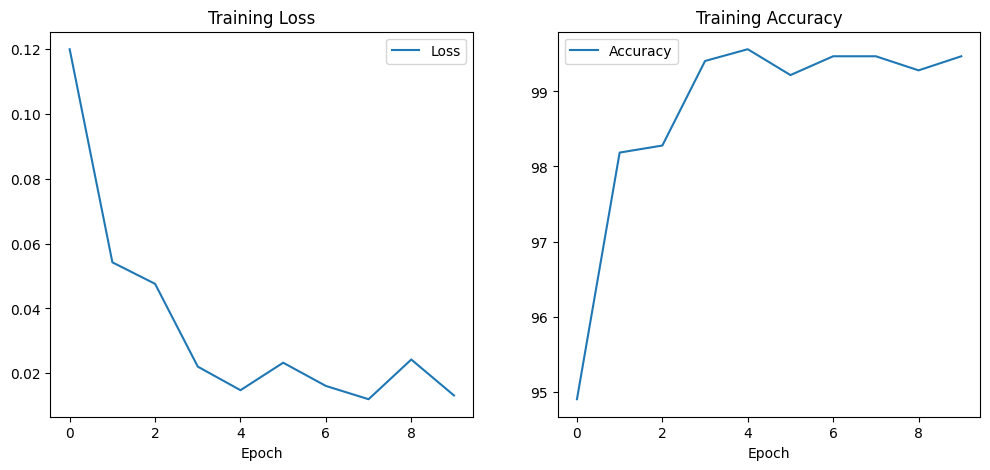

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.show()